In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.interpolate import interp1d

In [2]:
# --- IMPORTING FROM OTHER FILES
import sys
import os

# Add path to the package: relativistic_dof
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from relativistic_dof import RelativisticDOFRegistry
from maxim_distribution_analysis import AxionModelMaximDistribution

In [3]:
# --- HELPFULL FUNCTIONS
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx, array[idx]

## Configure the Setup and Select the Production Channel

In this section, we choose the axion production process to analyze and set flags that control output behavior (e.g., saving plots or data). Additional parameters:

- `file_number`: We define it, to select the process:
  - $0$ : Electron scattering
  - $1$ : Muon decay
  - $2$ : Muon scattering
  - $3$ : Tau decay
  - $4$ : Tau scattering
- `data_dir`: Directory containing input data files.
- `x_decouple`: Defined as $x = \frac{m}{T}$, where:
  - $m$ : Mass of the interacting particle,
  - $T$ : Temperature of the Universe.  
  This parameter sets the decoupling moment of axions, which is assumed to be fixed in this analysis.


In [4]:
# --- SELECT FILE, SET FLAGS (MANUAL) ---
file_number = 4
flag_save_plot_warmDM = False
flag_save_plot_comparison = False
flag_save_data = False
data_dir = "data-new"
x_decouple = 30

### Load Data and Compute Results

This part of the notebook performs the core data loading and processing. Two dictionaries are created during this step:

- `our_data`: Contains the results from our own axion distribution analysis. Keys:
  - `fa`: Axion decay constant.
  - `ya`: Axion abundance.
  - `delta_neff`: Extra relativistic degrees of freedom.

- `maxim_data`: Contains reference results imported from Maxim’s simulations or calculations.  
  This includes the same physical quantities (`fa`, `delta_neff`, and `ya`), derived from external files.

The analysis proceeds through four main steps:

1. **Select filenames and titles** based on the chosen production channel.
2. **Specify particle masses** and instantiate the axion model for numerical integration.
3. **Load external ΔN_eff data** (Maxim’s results) and postprocess them.
4. **Print key diagnostics** such as number of data points and entropy-related degrees of freedom.


In [5]:
# --- Define process labels and corresponding filenames for selected production channel ---
title_arr = [r"$\bf e$ scattering", r"$\bf \mu$ decay", r"$\bf \mu$ scattering",
             r"$\bf \tau$ decay", r"$\bf \tau$ scattering"]
filename_neff_arr = ["dNeff_fa_e_scat.dat", "dNeff_fa_mu_dec.dat", "dNeff_fa_mu_scat.dat", 
                     "dNeff_fa_tau_dec.dat", "dNeff_fa_tau_scat.dat"]
filename_dist_arr = ["Distributions_fa_e_scat.dat", "Distributions_fa_mu_dec.dat", "Distributions_fa_mu_scat.dat",
                     "Distributions_fa_tau_dec.dat", "Distributions_fa_tau_scat.dat"]
filename_save_plots_arr = ["e_scatterings", "mu_decay", "mu_scattering", "tau_decay", "tau_scattering"]
################################## WITH LOWER VALUE OF FA FOR TAON DECAYS ##########################################
# filename_neff_arr2 = ["dNeff_fa_e_scat.dat", "dNeff_fa_mu_dec.dat", "dNeff_fa_mu_scat.dat",
#                      "dNeff_fa_tau_dec_low_f.dat", "dNeff_fa_tau_scat_extended.dat"]
# filename_dist_arr2 = ["Distributions_fa_e_scat.dat", "Distributions_fa_mu_dec.dat", "Distributions_fa_mu_scat.dat",
#                      "Distributions_fa_tau_dec_low_f.dat", "Distributions_fa_tau_scat_extended.dat"]
####################################################################################################################
filename_neff = f"./{data_dir}/{filename_neff_arr[file_number]}"  # File with fa and ΔN_eff
filename_dist = f"./{data_dir}/{filename_dist_arr[file_number]}"  # File with distribution
filename_save_plots = f"{filename_save_plots_arr[file_number]}"

In [6]:
# --- Define particle masses [in eV] ---
electron_mass = 0.511e6      # [eV]
muon_mass = 105.66e6         # [eV]
tau_mass = 1777e6            # [eV]
particle_arr = [electron_mass, muon_mass, muon_mass, tau_mass, tau_mass]

# --- Initialize axion model and extract distribution-based results ---

# Create an instance of the axion model using:
# - the selected distribution file,
# - the mass of the interacting particle,
# - the chosen decoupling point (x = m/T)
axionModel = AxionModelMaximDistribution(
    filename_dist,
    particle_arr[file_number],
    x_decouple
)

# Compute and retrieve ΔN_eff and axion abundance as functions of fa
our_data = axionModel.get_neff_and_ya_vs_fa()

In [7]:
# --- Load external ΔN_eff results from Maxim's simulation ---

# Read the reference data (fa, delta_neff) from file, skipping the header row
data = np.loadtxt(filename_neff, delimiter=",", skiprows=1)

# Initialize dictionary to store processed data
maxim_data = dict()
maxim_data["fa"] = data[:, 0]                            # Axion decay constant [GeV]
maxim_data["N"] = len(data[:, 0])                        # Number of data points
maxim_data["delta_neff_nBE"] = data[:, 1]                # ΔN_eff assuming non-Bose-Einstein (nBE)
maxim_data["delta_neff_fBE"] = data[:, 2]                # ΔN_eff assuming full Bose-Einstein (fBE)

# Estimate axion abundance from ΔN_eff, formula from: 2410.18186
# ya = (ΔN_eff / 74.85)^(3/4), g_s = 43/11 (base)
# ya = (ΔN_eff / 75.64)^(3/4), g_s = 3.94  (more accurate)
maxim_data["ya_nBE"] = [(dNeff / 75.64)**(3/4) for dNeff in maxim_data["delta_neff_nBE"]]

In [8]:
# --- Print basic diagnostics for verification ---

# Number of data points loaded from Maxim's file
N_distribution_Maxim = len(maxim_data["fa"])
print("Number of points from Maxim's ΔN_eff file:", N_distribution_Maxim)

# Retrieve key physical constants from the axion model
decouple_dof_g_s = axionModel.get_physical_constant("g_star_s_axion_decoupling")
print("Entropy degrees of freedom at axion decoupling (g*_s):", decouple_dof_g_s)

g_star_s_today = axionModel.get_physical_constant("g_star_s_today")
print("Entropy degrees of freedom today (g*_s^0):", g_star_s_today)

Number of points from Maxim's ΔN_eff file: 200
Entropy degrees of freedom at axion decoupling (g*_s): 14.9413342440807
Entropy degrees of freedom today (g*_s^0): 3.931


## Sanity Check — Compare Our Results to Maxim's Data

In this section, we verify that our implementation correctly reproduces the reference results from Maxim's data files. In particular, we compare the calculated values of  $\Delta N_{\text{eff}}$ using our integration of his distribution with the original values reported in the files. This is an important consistency check to ensure that:
- We’re interpreting and integrating the distribution data correctly,
- The numerical methods are properly implemented,
- Any observed differences are physical and not due to a bug or misalignment.

We will visualize the comparison in the plot below.


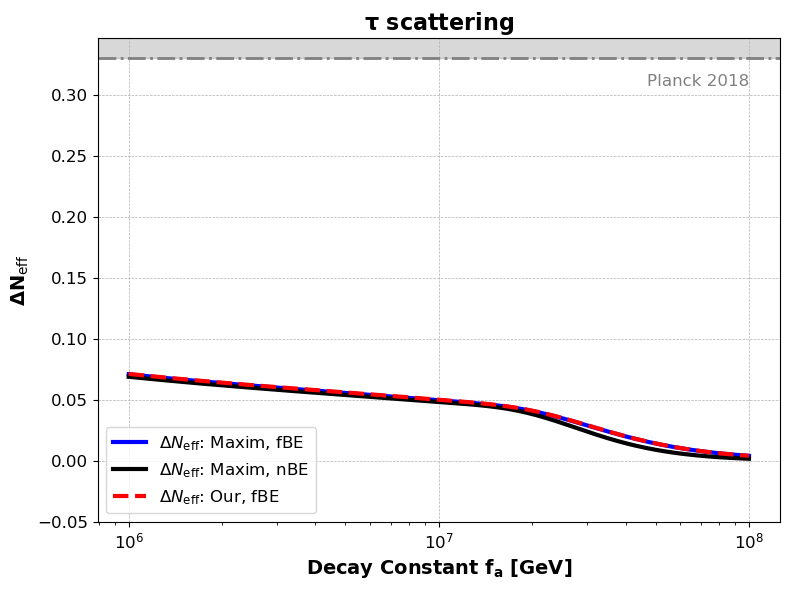

In [9]:
# --- Plot ΔN_eff: Our Results vs Maxim's Reference Data ---

fig, axs = plt.subplots(figsize=(8, 6))

# --- Plot Maxim's ΔN_eff results (fBE and nBE) ---
axs.plot(maxim_data["fa"], maxim_data["delta_neff_fBE"], color='blue', lw=3,
         label=r'$\Delta N_{\rm eff}$: Maxim, fBE')
axs.plot(maxim_data["fa"], maxim_data["delta_neff_nBE"], color='black', lw=3,
         label=r'$\Delta N_{\rm eff}$: Maxim, nBE')

# --- Plot Our ΔN_eff results (from integration using Maxim's distribution) ---
axs.plot(our_data["fa"], our_data["delta_neff"], color='red', lw=3, linestyle='--',
         label=r'$\Delta N_{\rm eff}$: Our, fBE')

# --- Axis scaling and labels ---
axs.set_xscale('log')
axs.set_xlabel(r'Decay Constant $\bf f_a$ [GeV]', fontsize=14, fontweight='bold')
axs.set_ylabel(r'$\bf \Delta N_{\rm eff}$', fontsize=14, fontweight='bold')
axs.set_title(title_arr[file_number], fontsize=16, fontweight='bold')

# --- Grid and legend ---
axs.grid(True, linestyle='--', linewidth=0.5)
axs.legend(fontsize=12)

# --- Planck 2018 constraint line and shaded exclusion area ---
planck_limit = 0.33
axs.axhline(planck_limit, color='gray', linestyle='-.', lw=2)
axs.text(maxim_data["fa"][-1], planck_limit - 0.025, 'Planck 2018',
         color='gray', fontsize=12, va='bottom', ha='right')

# Shade region above Planck limit
ymin, ymax = axs.get_ylim()
xmin, xmax = axs.get_xlim()
axs.set_xlim(xmin, xmax)
axs.set_ylim(-0.05, ymax)
xaxes = np.linspace(xmin, xmax, num=50)
axs.fill_between(xaxes, planck_limit, ymax, color='gray', alpha=0.3)

# --- Log-scale x-axis tick formatting ---
axs.xaxis.set_major_locator(ticker.LogLocator(base=10.0))
axs.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda val, pos: f'$10^{{{int(np.log10(val))}}}$')
)
axs.tick_params(axis='x', which='major', labelsize=12)
axs.tick_params(axis='y', which='major', labelsize=12)

# --- Display or save the figure ---
plt.tight_layout()
plt.show()

if flag_save_plot_comparison:
    plt.savefig('Maxim_vs_Our_delta_Neff.png', format='png', dpi=300)
    plt.close()


### Delta_neff: MAXIM RESULTS VS OUR INTEGRATION

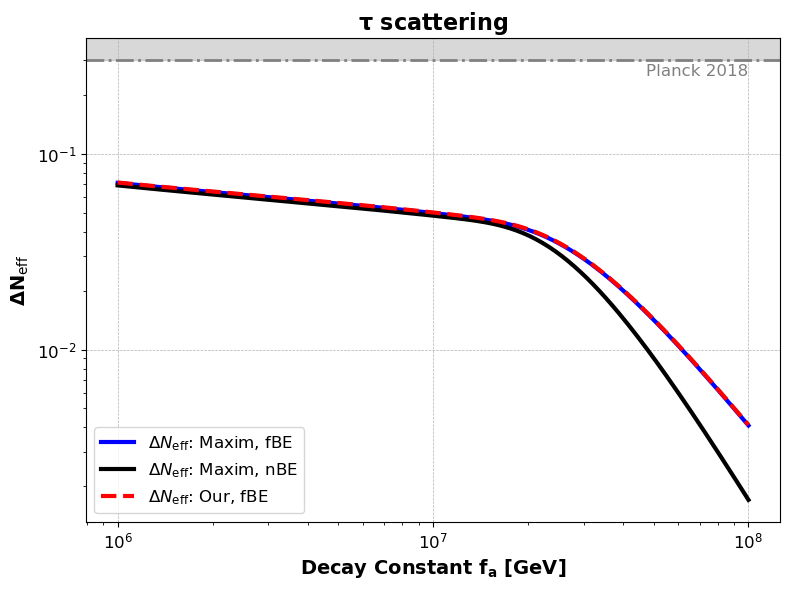

In [10]:
# --- Log-Log Plot: ΔN_eff — Our Integration vs Maxim's Data ---

fig, ax = plt.subplots(figsize=(8, 6))

# --- Plot Maxim's ΔN_eff values ---
ax.plot(maxim_data["fa"], maxim_data["delta_neff_fBE"], color='blue', lw=3,
        label=r'$\Delta N_{\rm eff}$: Maxim, fBE')
ax.plot(maxim_data["fa"], maxim_data["delta_neff_nBE"], color='black', lw=3,
        label=r'$\Delta N_{\rm eff}$: Maxim, nBE')

# --- Plot Our computed ΔN_eff from distribution integration ---
ax.plot(our_data["fa"], our_data["delta_neff"], color='red', lw=3, linestyle="--",
        label=r'$\Delta N_{\rm eff}$: Our, fBE')

# --- Set both axes to log scale ---
ax.set_xscale('log')
ax.set_yscale('log')

# --- Axis labels and plot title ---
ax.set_xlabel(r'Decay Constant $\bf f_a$ [GeV]', fontsize=14, fontweight='bold')
ax.set_ylabel(r'$\bf \Delta N_{\rm eff}$', fontsize=14, fontweight='bold')
ax.set_title(title_arr[file_number], fontsize=16, fontweight='bold')

# --- Grid and legend ---
ax.grid(True, linestyle='--', linewidth=0.5)
ax.legend(fontsize=12)

# --- Planck 2018 constraint line and shaded region ---
planck_limit = 0.30
ax.axhline(planck_limit, color='gray', linestyle='-.', lw=2)

# Add text label on the constraint line
ax.text(maxim_data["fa"][-1], planck_limit * 0.8, 'Planck 2018',
        color='gray', fontsize=12, va='bottom', ha='right')

# Shade region above Planck constraint
ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
xaxes = np.linspace(xmin, xmax, num=50)
ax.fill_between(xaxes, planck_limit, ymax, color='gray', alpha=0.3)

# --- Log-scale tick formatting on x-axis ---
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0))
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda val, pos: f'$10^{{{int(np.log10(val))}}}$')
)
ax.tick_params(axis='x', which='major', labelsize=12)
ax.tick_params(axis='y', which='major', labelsize=12)

# --- Layout and save/display ---
plt.tight_layout()
plt.show()

if flag_save_plot_comparison:
    plt.savefig('Maxim_vs_Our_delta_Neff_loglog.png', format='png', dpi=300)
    plt.close()


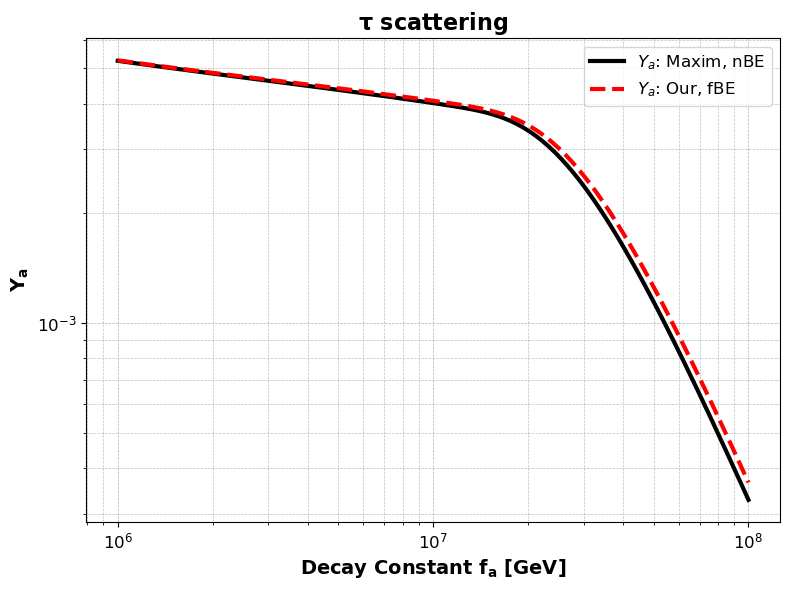

In [11]:
# --- Log-Log Plot: Axion Abundance (Y_a), Our Integration vs Maxim's Data ---

fig, ax = plt.subplots(figsize=(8, 6))

# --- Plot Maxim's Y_a values (nBE) ---
ax.plot(maxim_data["fa"], maxim_data["ya_nBE"], color='black', lw=3,
        label=r'$Y_a$: Maxim, nBE')

# --- Plot Our computed Y_a from distribution integration ---
ax.plot(our_data["fa"], our_data["ya"], color='red', lw=3, linestyle="--",
        label=r'$Y_a$: Our, fBE')

# --- Set both axes to log scale ---
ax.set_xscale('log')
ax.set_yscale('log')

# --- Axis labels and plot title ---
ax.set_xlabel(r'Decay Constant $\bf f_a$ [GeV]', fontsize=14, fontweight='bold')
ax.set_ylabel(r'$\bf Y_{a}$', fontsize=14, fontweight='bold')
ax.set_title(title_arr[file_number], fontsize=16, fontweight='bold')

# --- Grid and legend ---
ax.grid(True, linestyle='--', linewidth=0.5)
ax.legend(fontsize=12)

# --- Minor ticks and enhanced grid for log-scale x-axis ---
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(1, 10), numticks=100))
ax.grid(True, which='minor', linestyle='--', linewidth=0.5, color='gray', alpha=0.5)

# --- Tick styling ---
ax.tick_params(axis='x', which='major', labelsize=12)
ax.tick_params(axis='y', which='major', labelsize=12)

# --- Final layout and display ---
plt.tight_layout()
plt.show()

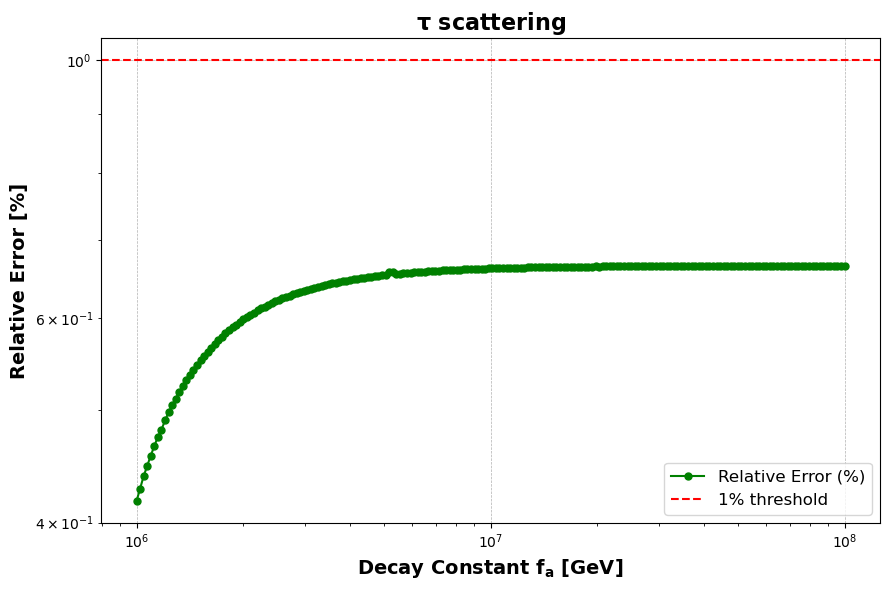

In [12]:
# --- Plot: Relative Error Between Our and Maxim's ΔN_eff (Log-Log) ---

fig, ax = plt.subplots(figsize=(9, 6))

# --- Compute relative difference (in percent) ---
# Avoid division by zero: only compute where Maxim's ΔNeff ≠ 0
rel_diff_arr = (
    np.abs(maxim_data["delta_neff_fBE"] - our_data["delta_neff"]) /
    np.abs(maxim_data["delta_neff_fBE"])
) * 100

# Plot relative error as a function of f_a
ax.plot(maxim_data["fa"], rel_diff_arr, 'go-', label=r'Relative Error (%)', markersize=5)

# --- Reference line for 1% threshold ---
ax.axhline(y=1, color='red', linestyle='--', label='1% threshold')

# --- Axis labels and plot title ---
ax.set_xlabel(r'Decay Constant $\bf f_a$ [GeV]', fontsize=14, fontweight='bold')
ax.set_ylabel(r'Relative Error [%]', fontsize=14, fontweight='bold')
ax.set_title(title_arr[file_number], fontsize=16, fontweight='bold')

# --- Set log-log scale for better visibility across orders of magnitude ---
ax.set_xscale('log')
ax.set_yscale('log')

# --- Grid and legend ---
ax.grid(True, linestyle='--', linewidth=0.5)
ax.legend(fontsize=12)

# --- Final layout and display ---
plt.tight_layout()
plt.show()

## Cosmological Constraints on Axion Dark Matter

Now that we've validated our axion distribution results, we use them to determine cosmologically viable regions in parameter space.

We consider the following scenarios:

- **Axion as full dark matter (ωₐ = 0.12)**  
- **Axion as partial dark matter (15% of DM, ωₐ ≈ 0.018)**  

These two cases represent extremes: axions making up all of DM or just a warm subcomponent.  
Warm dark matter is strongly constrained by structure formation — typically no more than $~15%$ of DM can be warm (e.g. arXiv:1111.0293, 1306.3996). 

We'll explore how different axion masses and decay constants $(f_a, m_a)$ affect whether a given model overproduces CDM or violates WDM bounds.

In [13]:
# --- Helper: Thermal axion mass from fixed ωₐ and ΔN_eff ---
def get_ma_fixed_wa_thermal(_fixed_wa, _delta_neff):
    """
    Estimate axion mass from fixed energy density ωₐ and ΔN_eff using the thermal relic formula:
        m_a = ωₐ / 0.011 × (ΔN_eff)^(-3/4)
    """
    ma_arr = _fixed_wa / 0.011 * _delta_neff ** (-3 / 4)
    return ma_arr

# --- Fix values of axion energy density ωₐ ---
wa_fixed_1 = 0.12                 # Axion as full dark matter
wa_fixed_2 = 0.15 * wa_fixed_1    # Axion as 15% of dark matter (WDM limit)

# --- Non-thermal (our model) axion mass from ωₐ ---
our_ma_arr_1 = axionModel.get_ma_fixed_wa(wa_fixed_1)
our_ma_arr_2 = axionModel.get_ma_fixed_wa(wa_fixed_2)

# --- Thermal mass estimate using Maxim's ΔN_eff ---
our_ma_thermal_arr_1 = get_ma_fixed_wa_thermal(wa_fixed_1, maxim_data["delta_neff_nBE"])
our_ma_thermal_arr_2 = get_ma_fixed_wa_thermal(wa_fixed_2, maxim_data["delta_neff_nBE"])

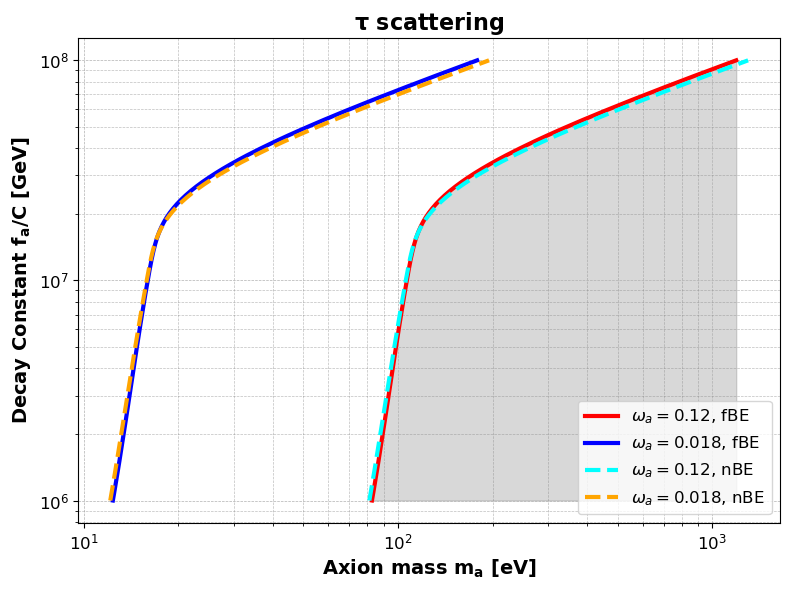

In [14]:
# --- Plot constraints in (m_a, f_a) plane ---

fig, ax = plt.subplots(figsize=(8, 6))

# Non-thermal scenario (our results)
ax.plot(our_ma_arr_1, our_data["fa"], color='red', lw=3, linestyle="-", label=r'$\omega_a = 0.12$, fBE')
ax.plot(our_ma_arr_2, our_data["fa"], color='blue', lw=3, linestyle="-", label=r'$\omega_a = 0.018$, fBE')

# Thermal relic scenario using Maxim's ΔN_eff
ax.plot(our_ma_thermal_arr_1, our_data["fa"], color='cyan', lw=3, linestyle="--", label=r'$\omega_a = 0.12$, nBE')
ax.plot(our_ma_thermal_arr_2, our_data["fa"], color='orange', lw=3, linestyle="--", label=r'$\omega_a = 0.018$, nBE')

# --- Log scale for both axes ---
ax.set_xscale('log')
ax.set_yscale('log')

# --- Labels and title ---
ax.set_xlabel(r'Axion mass $\bf m_a$ [eV]', fontsize=14, fontweight='bold')
ax.set_ylabel(r'Decay Constant $\bf f_a/C$ [GeV]', fontsize=14, fontweight='bold')
ax.set_title(title_arr[file_number], fontsize=16, fontweight='bold')

# --- Grid and legend ---
ax.grid(True, linestyle='--', linewidth=0.5)
ax.legend(fontsize=12, loc='lower right', frameon=True)

# --- Minor log ticks and styling ---
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(1, 10), numticks=100))
ax.grid(True, which='minor', linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

#####################################################################################################################################
# WORKING PREGRESS
# --- Shade excluded region: above red line (ωₐ = 0.12) is overproduction --- (PART 1)
ax.fill_between(our_ma_arr_1, our_data["fa"], y2=min(our_data["fa"]),
                where=(our_ma_arr_1 >= our_ma_arr_1[0]),
                interpolate=True, color='gray', alpha=0.3, label="Excluded")

# # --- Update plot limits before drawing --- (PART 2)
# # plt.tight_layout()
# # plt.draw()

# # --- Define thresholds dynamically from data ---
# ma_threshold = max(our_ma_arr_1)   # e.g. 1e3
# fa_ceiling   = max(our_data["fa"])  # e.g. 1e8

# # --- Draw horizontal band from ma_threshold to right edge ---
# ax.axhspan(ymin=ax.get_ylim()[0], ymax=fa_ceiling,
#            xmin=np.log10(ma_threshold),
#            xmax=np.log10(ax.get_xlim()[1]),
#            color='gray', alpha=0.3,
#            label=fr'Excluded ($m_a > {ma_threshold:.0e}$ eV)')
#####################################################################################################################################

# --- Save and display ---
plt.tight_layout()
if flag_save_plot_warmDM:
    plt.savefig(f'{filename_save_plots}_DM_constrain.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
# --- FIND CONSTRAIN ON AXION: MINIMUM TEMPERATURE SCENARIO
# For this case we assume the smallest possible contribution to ΔN_eff=0.027.
# This can be possible, if axion (or any otehr light species) thermalised and
# decouple before top quark, when g_*s = 106.75

minimal_deltaNeff = 0.027

# Find fa, when we produce minimal ΔN_eff
fBE_index, fBE_minimal_deltaNeff = find_nearest(our_data["delta_neff"], minimal_deltaNeff)
nBE_index, nBE_minimal_deltaNeff = find_nearest(maxim_data["delta_neff_nBE"], minimal_deltaNeff)

print(f"in fBE nearest to ΔN_eff=0.027 is: ΔN_eff={fBE_minimal_deltaNeff:.4e}")
print(f"in nBE nearest to ΔN_eff=0.027 is: ΔN_eff={nBE_minimal_deltaNeff:.4e}")

# Find upper constrai on ma
upper_ma_fBE_2 = our_ma_arr_2[fBE_index]
upper_ma_nBE_2 = our_ma_thermal_arr_2[fBE_index]

print(f"fBE wDM: ma < {upper_ma_fBE_2:.4e} eV")
print(f"nBE wDM: ma < {upper_ma_nBE_2:.4e} eV")

print(f"fBE fa : fa = {our_data['fa'][fBE_index]:.4e} eV")

in fBE nearest to ΔN_eff=0.027 is: ΔN_eff=2.7012e-02
in nBE nearest to ΔN_eff=0.027 is: ΔN_eff=2.6650e-02
fBE wDM: ma < 2.7763e+01 eV
nBE wDM: ma < 2.9122e+01 eV
fBE fa : fa = 3.2176e+07 eV


### Saving Data — Extracting Viable Parameter Space

Now that we've constructed a reliable mapping between the axion decay constant $f_a$ and mass $m_a$ for a fixed axion abundance $omega_a$, we export this relationship for further use.

Specifically, we:
- Interpolate $f_a \leftrightarrow m_a$ in log-log space,
- Generate a dense grid of $f_a$ values,
- Evaluate the corresponding $m_a$,
- Save only points that lie in the physically viable region (e.g., $m_a < 200 \,\text{eV}$).

This output can later be used to:
- Constrain dark matter model parameters,
- Overlay exclusion regions from structure formation (e.g. Lyman-α),
- Compare against other cosmological datasets.


In [16]:
# --- Define fmin/fmax values for each channel ---
# Format: (log10(fmin), log10(fmax))
fa_log_ranges = [
    (6.0, 8.0),  # electron scattering
    (6.0, 9.0),  # muon decay
    (6.0, 8.0),  # muon scattering
    (4.5, 9.0),  # tau decay
    (4.0, 8.0),  # tau scattering
]

# --- Select appropriate range based on the selected process ---
fmin, fmax = fa_log_ranges[file_number]

# --- Create interpolation grid in log-space ---
nums = 500  # number of points in the interpolation grid
fa_targets = np.logspace(fmin, fmax, nums)  # 10^fmin to 10^fmax GeV

# --- Interpolate log10(fa) → log10(ma) ---
sorted_indices = np.argsort(our_data["fa"])
fa_sorted = np.array(our_data["fa"])[sorted_indices]
ma_sorted = np.array(our_ma_arr_2)[sorted_indices]

log_interp_inverse = interp1d(
    np.log10(fa_sorted),
    np.log10(ma_sorted),
    kind='linear',
    fill_value='extrapolate'
)

log_ma_targets = log_interp_inverse(np.log10(fa_targets))
ma_targets = 10**log_ma_targets

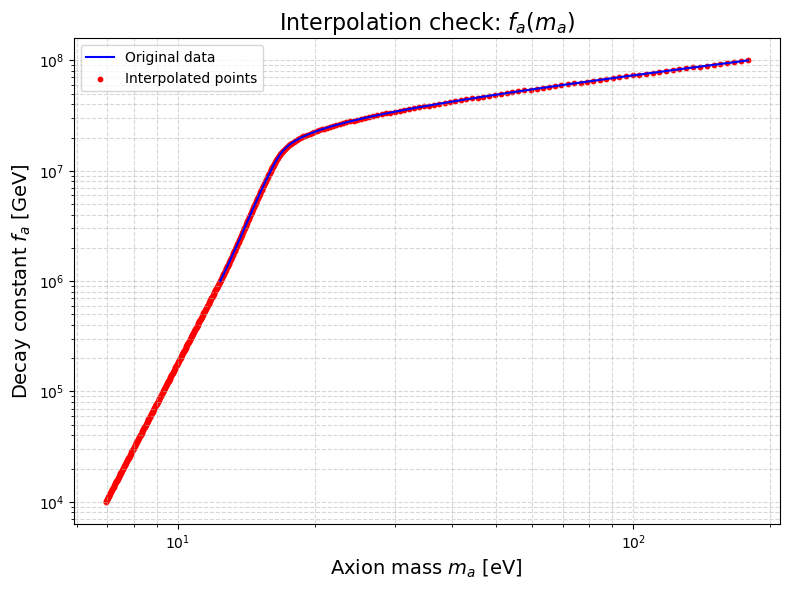

In [17]:
# --- Plot: Check inverse interpolation f_a vs m_a ---

plt.figure(figsize=(8, 6))
plt.loglog(our_ma_arr_2, our_data["fa"], label="Original data", color='blue')
plt.scatter(ma_targets, fa_targets, color='red', label="Interpolated points", s=10)

plt.xlabel("Axion mass $m_a$ [eV]", fontsize=14)
plt.ylabel("Decay constant $f_a$ [GeV]", fontsize=14)
plt.title("Interpolation check: $f_a(m_a)$", fontsize=16)
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# --- Save (f_a, m_a) pairs that satisfy filtering conditions ---
if flag_save_data:
    with open(f"warmDM_fa_ma_{filename_save_plots}.dat", "w") as f:
        f.write("#fa/C\tma\n")
        for fa, m in zip(fa_targets, ma_targets):
            if m < 200:  # Filter condition to exclude heavy axions
                f.write(f"{fa:.6e}\t{m:.6e}\n")